EDA

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# Load dataset
train_path = "Dataset/sign_mnist_train/sign_mnist_train.csv"
test_path = "Dataset/sign_mnist_test/sign_mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\n===== TRAIN INFO =====")
print(train_df.info())

print("\n===== TEST INFO =====")
print(test_df.info())

print("\n===== FIRST 5 ROWS =====")
print(train_df.head())

Train shape: (27455, 785)
Test shape : (7172, 785)

===== TRAIN INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
None

===== TEST INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 7172 entries, 0 to 7171
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 43.0 MB
None

===== FIRST 5 ROWS =====
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207      

In [24]:
# Check missing values
print("\n===== MISSING VALUES =====")
print("Train missing values:")
print(train_df.isnull().sum().sum())

print("Test missing values:")
print(test_df.isnull().sum().sum())

# Check duplicate row
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print("\n===== DUPLICATES =====")
print("Train duplicates:", train_duplicates)
print("Test duplicates :", test_duplicates)




===== MISSING VALUES =====
Train missing values:
0
Test missing values:
0

===== DUPLICATES =====
Train duplicates: 0
Test duplicates : 0


In [25]:
# Separate features and labels
X_train = train_df.drop("label", axis=1)
y_train = train_df["label"]

X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)




X_train shape: (27455, 784)
y_train shape: (27455,)
X_test shape : (7172, 784)
y_test shape : (7172,)



===== UNIQUE LABELS =====
Train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Test labels : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]

===== TRAIN CLASS COUNTS =====
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    116

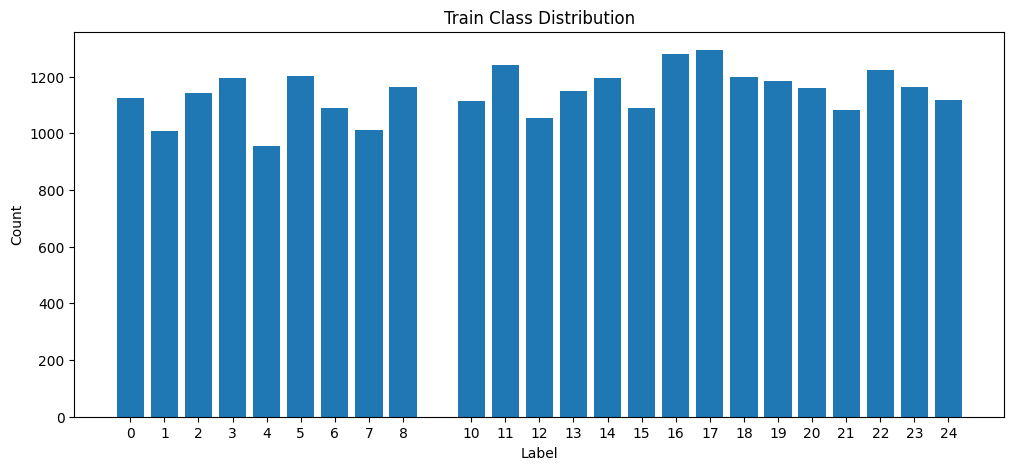

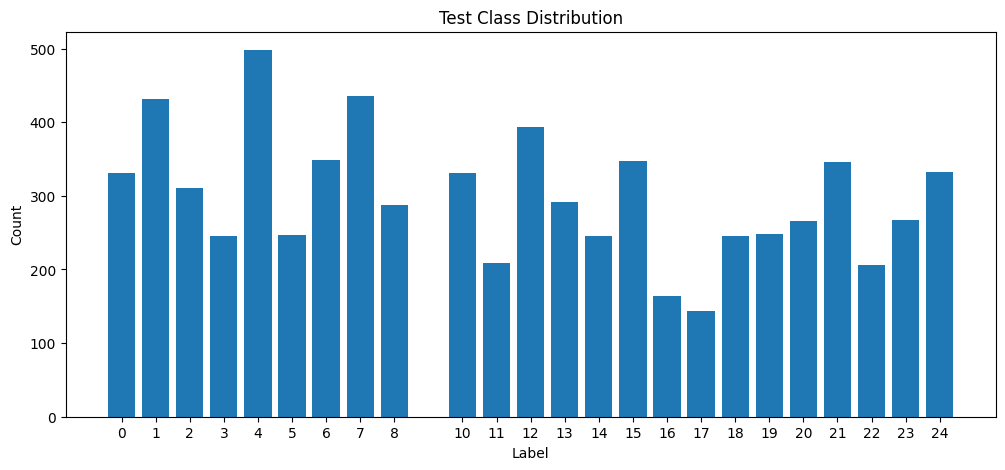

In [26]:
# 5) Unique labels and class distribution
print("\n===== UNIQUE LABELS =====")
print("Train labels:", sorted(y_train.unique()))
print("Test labels :", sorted(y_test.unique()))

train_class_counts = y_train.value_counts().sort_index()
test_class_counts = y_test.value_counts().sort_index()

print("\n===== TRAIN CLASS COUNTS =====")
print(train_class_counts)

print("\n===== TEST CLASS COUNTS =====")
print(test_class_counts)

# Plot class distribution
plt.figure(figsize=(12, 5))
plt.bar(train_class_counts.index, train_class_counts.values)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Train Class Distribution")
plt.xticks(train_class_counts.index)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(test_class_counts.index, test_class_counts.values)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Test Class Distribution")
plt.xticks(test_class_counts.index)
plt.show()

In [27]:
# Label mapping
# Sign Language MNIST  skips J (9) and Z (25)
label_map = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E',
    5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K',
    10: 'L', 11: 'M', 12: 'N', 13: 'O', 14: 'P',
    15: 'Q', 16: 'R', 17: 'S', 18: 'T', 19: 'U',
    20: 'V', 21: 'W', 22: 'X', 23: 'Y'
}

print("\n===== LABEL MAP =====")
print(label_map)


===== LABEL MAP =====
{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'O', 14: 'P', 15: 'Q', 16: 'R', 17: 'S', 18: 'T', 19: 'U', 20: 'V', 21: 'W', 22: 'X', 23: 'Y'}



Showing random sample images from training set...


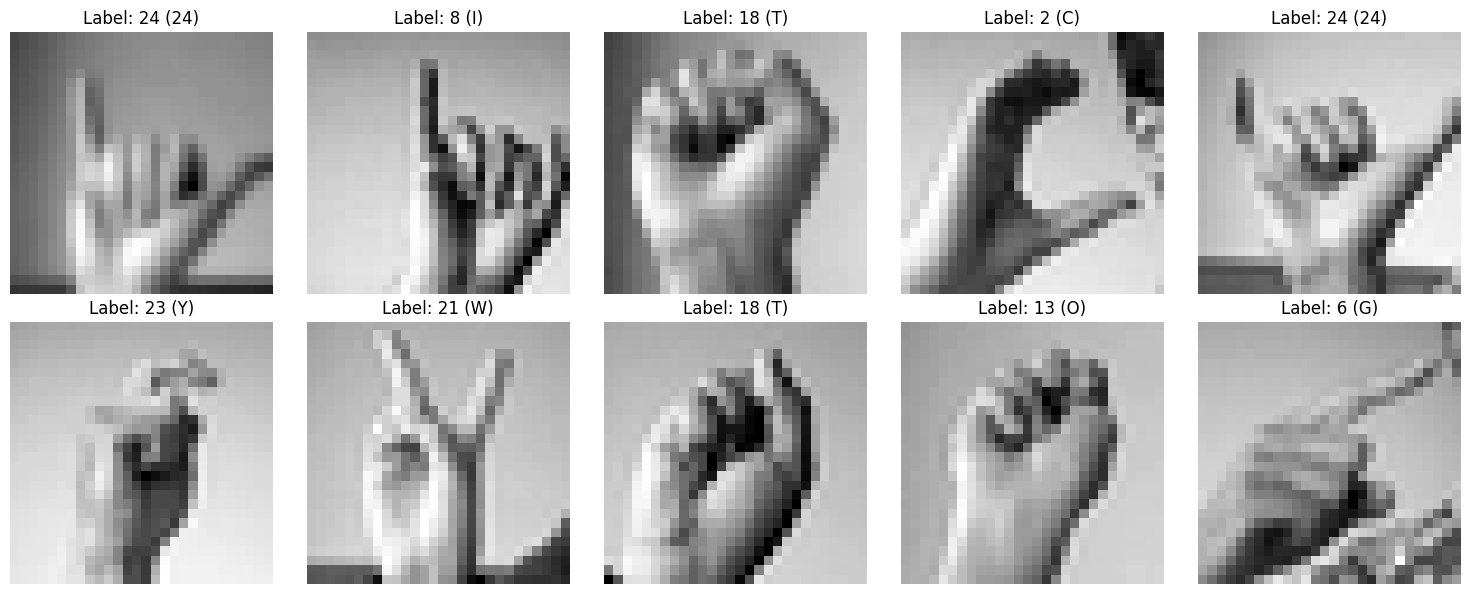

In [28]:
#  Show sample images
def show_samples(df, label_col="label", n=10):
    plt.figure(figsize=(15, 6))
    sample_df = df.sample(n=n, random_state=42).reset_index(drop=True)

    for i in range(n):
        image = sample_df.iloc[i].drop(label_col).values.reshape(28, 28)
        label = sample_df.iloc[i][label_col]
        label_name = label_map.get(label, str(label))

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Label: {label} ({label_name})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

print("\nShowing random sample images from training set...")
show_samples(train_df, n=10)


Showing one sample per class...


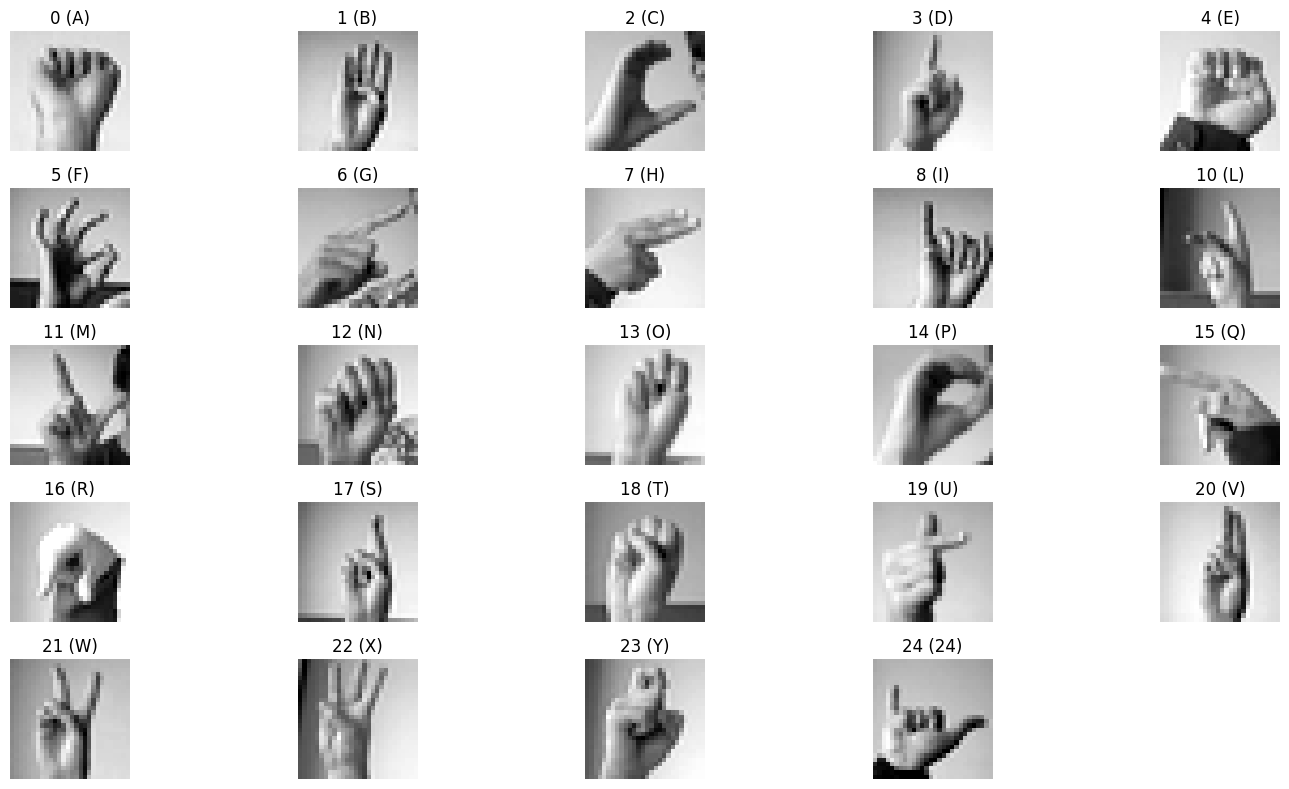

In [29]:
# Show one sample per class

def show_one_per_class(df, label_col="label"):
    unique_labels = sorted(df[label_col].unique())
    num_classes = len(unique_labels)

    plt.figure(figsize=(15, 8))
    for i, lbl in enumerate(unique_labels):
        row = df[df[label_col] == lbl].iloc[0]
        image = row.drop(label_col).values.reshape(28, 28)
        label_name = label_map.get(lbl, str(lbl))

        plt.subplot(5, 5, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"{lbl} ({label_name})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

print("\nShowing one sample per class...")
show_one_per_class(train_df)

In [30]:
# Pixel statistics
print("\n===== PIXEL STATISTICS =====")
print("Train pixel min :", X_train.min().min())
print("Train pixel max :", X_train.max().max())
print("Train pixel mean:", X_train.values.mean())
print("Train pixel std :", X_train.values.std())

print("Test pixel min  :", X_test.min().min())
print("Test pixel max  :", X_test.max().max())
print("Test pixel mean :", X_test.values.mean())
print("Test pixel std  :", X_test.values.std())


===== PIXEL STATISTICS =====
Train pixel min : 0
Train pixel max : 255
Train pixel mean: 159.2910081989452
Train pixel std : 48.76950534451025
Test pixel min  : 0
Test pixel max  : 255
Test pixel mean : 160.5711415282789
Test pixel std  : 49.04255373886974


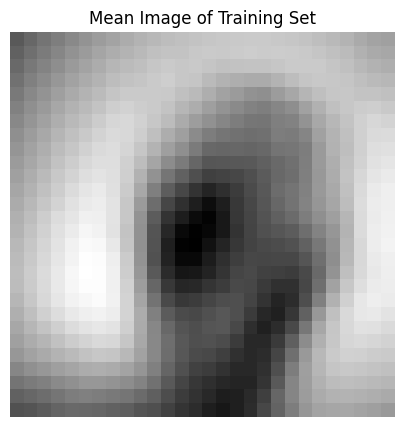

In [31]:
# Mean image of entire dataset
mean_image = X_train.mean(axis=0).values.reshape(28, 28)

plt.figure(figsize=(5, 5))
plt.imshow(mean_image, cmap="gray")
plt.title("Mean Image of Training Set")
plt.axis("off")
plt.show()

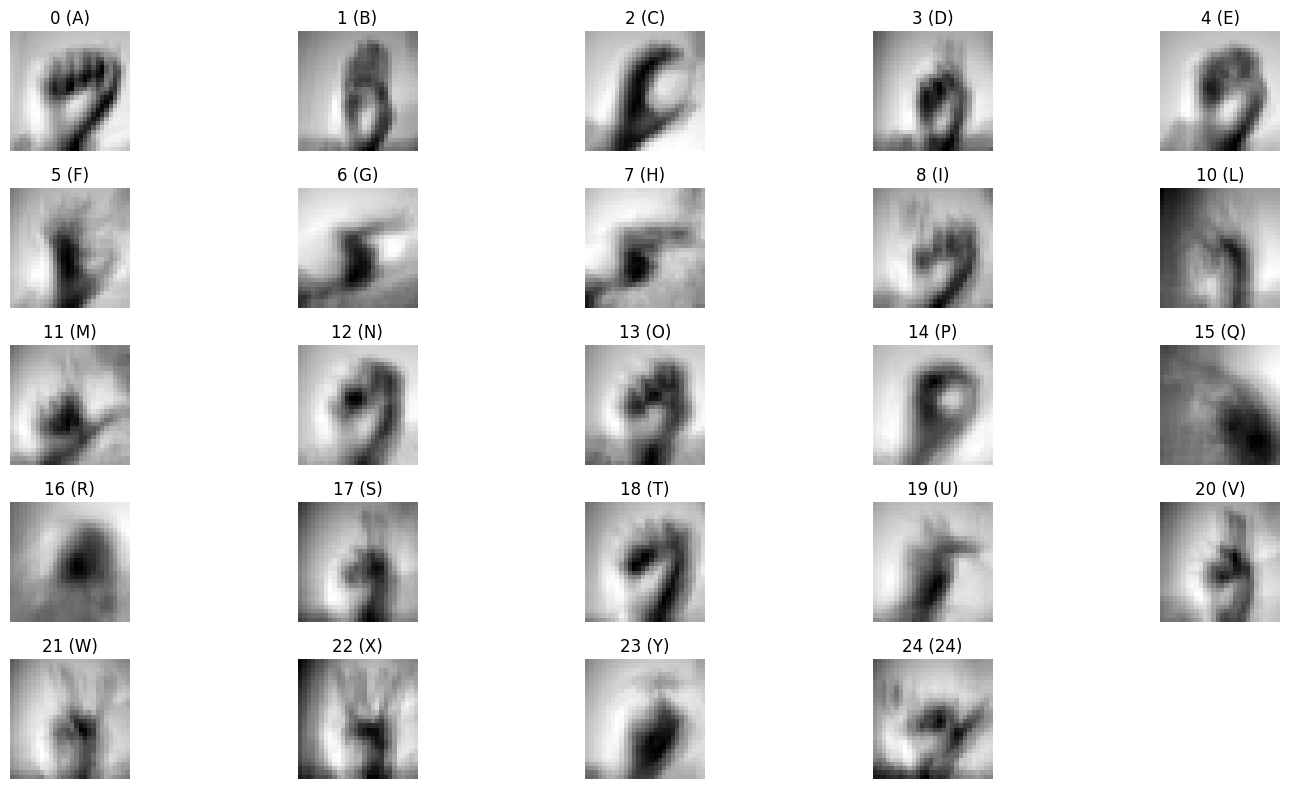

In [32]:
# Mean image per class
unique_labels = sorted(y_train.unique())
plt.figure(figsize=(15, 8))

for i, lbl in enumerate(unique_labels):
    class_images = train_df[train_df["label"] == lbl].drop("label", axis=1)
    mean_class_image = class_images.mean(axis=0).values.reshape(28, 28)
    label_name = label_map.get(lbl, str(lbl))

    plt.subplot(5, 5, i + 1)
    plt.imshow(mean_class_image, cmap="gray")
    plt.title(f"{lbl} ({label_name})")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#  summary
print("\n===== SUMMARY =====")
print(f"Number of training samples : {len(train_df)}")
print(f"Number of testing samples  : {len(test_df)}")
print(f"Number of classes          : {len(y_train.unique())}")
print(f"Image size                 : 28 x 28")
print(f"Pixel value range          : {X_train.min().min()} to {X_train.max().max()}")


===== SUMMARY =====
Number of training samples : 27455
Number of testing samples  : 7172
Number of classes          : 24
Image size                 : 28 x 28
Pixel value range          : 0 to 255
Train class balance        : Balanced enough
